<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance/blob/main/market_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import MetaTrader5 as mt5
import numpy as np
import pandas as pd

print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)

trade_active = mt5.initialize("C:\\Program Files\\MetaTrader 5\\terminal64.exe")

print(trade_active)

if not trade_active:
    print('Initialization failed, check internet connection. You must have Meta Trader 5 installed.')
    mt5.shutdown()

else:
    print(mt5.account_info()._asdict())
    print("\n")
    print(mt5.terminal_info()._asdict())
    print("\n")
    print(mt5.symbols_total())

account = mt5.account_info()
terminal = mt5.terminal_info()

print(account.equity)

if(terminal.connected == True or terminal.trade_allowed == True):
    print("AI is successfully functional")
else:
    print("Please make sure metatrade 5 has internet and algo Trade is Turn On")

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.5200
True
{'login': 49354034, 'trade_mode': 0, 'leverage': 500, 'limit_orders': 300, 'margin_so_mode': 0, 'trade_allowed': True, 'trade_expert': True, 'margin_mode': 2, 'currency_digits': 2, 'fifo_close': False, 'balance': 826.83, 'credit': 0.0, 'profit': 0.0, 'equity': 826.83, 'margin': 0.0, 'margin_free': 826.83, 'margin_level': 0.0, 'margin_so_call': 50.0, 'margin_so_so': 20.0, 'margin_initial': 0.0, 'margin_maintenance': 0.0, 'assets': 0.0, 'liabilities': 0.0, 'commission_blocked': 0.0, 'name': '#testing - Micheal Omage', 'server': 'HFMarketsGlobal-Demo', 'currency': 'USD', 'company': 'HF Markets (SV) Ltd.'}


{'community_account': False, 'community_connection': False, 'connected': True, 'dlls_allowed': False, 'trade_allowed': True, 'tradeapi_disabled': False, 'email_enabled': False, 'ftp_enabled': False, 'notifications_enabled': False, 'mqid': True, 'build': 5833, 'maxbars': 100000000, 'codepage': 0, 'p

In [2]:
t_s = "XAUUSD"
market = mt5.copy_rates_from_pos(t_s, mt5.TIMEFRAME_H1, 0, 9000000)
#display(market)
print(market.shape)

print(t_s)

# GOLD is 5 mins while GBPUSD is 15 mins

data = []
for i in range(len(market)):
    data.append([market[i][0],market[i][1],market[i][2],market[i][3],market[i][4],market[i][5]])
df = pd.DataFrame(data, columns=["time","open", "high","low", "close","volume"])
df.to_csv("Generated"+t_s+" dbot.csv", index=False)
print("Current Action Done")

(43947,)
GBPUSD
Current Action Done


In [1]:
import MetaTrader5 as mt5
import pandas as pd

def fetch_rates(symbol, timeframe, count=9_000_000):
    """Pull rates from MT5 and return a tidy DataFrame."""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, count)
    
    if rates is None:
        raise ValueError(f"MT5 returned None for {symbol}. Error: {mt5.last_error()}")
    
    df = pd.DataFrame(rates)
    
    # ── Debug: show what columns MT5 actually gave us ──────────────────────
    print(f"Available columns: {list(df.columns)}")
    
    # ── Grab volume column whatever it is called ────────────────────────────
    vol_col = next((c for c in df.columns if "volume" in c.lower()), None)
    if vol_col is None:
        raise KeyError(f"No volume column found among: {list(df.columns)}")
    
    df = df[["time", "open", "high", "low", "close", vol_col]].copy()
    df.rename(columns={vol_col: "volume"}, inplace=True)
    #df["time"] = pd.to_datetime(df["time"], unit="s")
    return df.set_index("time")


def build_multi_tf(symbol):
    if not mt5.initialize():
        raise RuntimeError(f"MT5 initialize() failed: {mt5.last_error()}")

    try:
        df_1h = fetch_rates(symbol, mt5.TIMEFRAME_H1)
        df_4h = fetch_rates(symbol, mt5.TIMEFRAME_H4)
        df_1d = fetch_rates(symbol, mt5.TIMEFRAME_D1)
    except Exception as e:
        print(f"Error fetching rates: {e}")
    def tag(df, suffix):
        return df.rename(columns={c: f"{c}_{suffix}" for c in df.columns})

    #df_1h = tag(df_1h, "1h").reset_index()
    df_4h = tag(df_4h, "4h").reset_index()
    df_1d = tag(df_1d, "1d").reset_index()

    # Both sides must be sorted for merge_asof
    df_1h = df_1h.sort_values("time")
    df_4h = df_4h.sort_values("time")
    df_1d = df_1d.sort_values("time")

    merged = pd.merge_asof(df_1h, df_4h, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_1d, on="time", direction="backward")

    return merged


# ── Run ────────────────────────────────────────────────────────────────────────
symbol = "XAUUSD"
df = build_multi_tf(symbol)

out_path = f"Generated{symbol} dbot.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved {len(df):,} rows → {out_path}")
print(df.head())

Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']

Saved 53,543 rows → GeneratedXAUUSD dbot.csv
         time   open   high    low  close  volume  open_4h  high_4h  low_4h  \
0  1196294400  803.7  807.7  792.0  792.8   11292    803.7    807.7   792.0   
1  1196380800  793.3  799.2  778.7  782.7   11315    793.3    799.2   778.7   
2  1196640000  783.8  794.5  776.8  794.3    9936    783.8    794.5   776.8   
3  1196726400  793.6  805.0  786.2  800.6    9730    793.6    805.0   786.2   
4  1196812800  801.0  806.5  790.8  794.8   11035    801.0    806.5   790.8   

   close_4h  volume_4h  open_1d  high_1d  low_1d  close_1d  volume_1d  
0     792.8      11292    803.7    807.7   792.0     792.8      11292  
1     782.7      11315    793.3    

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings

import joblib
from extra_function import RobustPriceLabelerV3, engineer_features, plot_signals, predict_and_plot_signals

#warnings.filterwarnings('ignore')

In [2]:


print("="*70)
print("TRADING SIGNAL CLASSIFICATION SYSTEM")
print("="*70)

# Step 1: Load data from Excel
print("\nStep 1: Loading data from Excel file...")
t_symbol = ["XAUUSD","#BTCUSD","GBPUSD","Volatility 100 (1s) Index","Step Index"] #GPBUSD is 1 hour and XAUUSD is 15 min data
n = 0
m_label = "Generated"+t_symbol[n]






TRADING SIGNAL CLASSIFICATION SYSTEM

Step 1: Loading data from Excel file...


In [3]:

df = pd.read_csv(m_label+ " dbot.csv")
df = engineer_features(df[:-200])

e:\GitHub\Dbot-Advance\extra_function.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')
e:\GitHub\Dbot-Advance\extra_function.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['time'].dt.month
e:\GitHub\Dbot-Advance\extra_function.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [4]:
df

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,open_1d,high_1d,low_1d,close_1d,volume_1d,month,day,hour,day_of_week
0,803.70,807.70,792.00,792.80,11292,803.70,807.70,792.00,792.80,11292,803.7,807.70,792.00,792.80,11292,11,29,0,3
1,793.30,799.20,778.70,782.70,11315,793.30,799.20,778.70,782.70,11315,793.3,799.20,778.70,782.70,11315,11,30,0,4
2,783.80,794.50,776.80,794.30,9936,783.80,794.50,776.80,794.30,9936,783.8,794.50,776.80,794.30,9936,12,3,0,0
3,793.60,805.00,786.20,800.60,9730,793.60,805.00,786.20,800.60,9730,793.6,805.00,786.20,800.60,9730,12,4,0,1
4,801.00,806.50,790.80,794.80,11035,801.00,806.50,790.80,794.80,11035,801.0,806.50,790.80,794.80,11035,12,5,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53338,4541.90,4545.89,4539.57,4543.16,4129,4541.90,4545.89,4525.41,4526.57,21397,4541.9,4545.89,4490.51,4509.11,281818,5,22,1,4
53339,4543.13,4544.86,4532.42,4535.41,4853,4541.90,4545.89,4525.41,4526.57,21397,4541.9,4545.89,4490.51,4509.11,281818,5,22,2,4
53340,4535.71,4540.96,4525.41,4526.57,12415,4541.90,4545.89,4525.41,4526.57,21397,4541.9,4545.89,4490.51,4509.11,281818,5,22,3,4
53341,4526.54,4536.06,4521.01,4526.26,15410,4526.54,4536.06,4518.53,4527.11,41506,4541.9,4545.89,4490.51,4509.11,281818,5,22,4,4


In [5]:

labeler = RobustPriceLabelerV3(
                atr_period      = 14,
                zigzag_atr_mult = 0.5,
                hold_bars       = 1,
                min_streak      = 0.01,
                target_hold_pct = 0.01 )


df = labeler.label(df)
print(df[["close", "label", "label_name", "label_conf"]].tail(20))
#df.to_csv("Generated gold"+" dbot.csv", index=False)
"""
from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5


labeler = RobustPriceLabelerV4(
    # ----- Core zigzag -----
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    hold_bars        = 2,
    min_streak       = 2,
    target_hold_pct  = 0.30,
    # ----- S/R zone filter (backward) -----
    sr_lookback      = 3,       # track last 3 swing H and 3 swing L
    zone_mult        = 1.0,     # block within 1 ATR of any S/R level
    # ----- Triple barrier (forward) -----
    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead
    # ----- Optional EMA momentum gate -----
    use_momentum_gate= False,   # set True for stricter trend-aligned labels
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)
print(
    df[["close", "label", "label_name", "label_conf",
            "zone_locked", "barrier_locked"]].tail(20).to_string()
)

from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5
labeler = RobustPriceLabelerV5(
    # Core zigzag
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    # S/R zone filter (backward)
    sr_lookback      = 3,       # track last 3 swing highs and 3 swing lows
    zone_mult        = 1.0,     # flip within 1 ATR of any S/R level
    # Triple-barrier (forward)
    profit_mult      = 1.5,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 20,      # 20 bars forward = 100 min on 5-min chart
    # EMA momentum gate (optional)
    use_momentum_gate= True,   # set True for trend-aligned labeling
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)

print(
    df[[
        "close", "label", "label_name", "label_conf",
        "zone_flipped", "barrier_flipped", "any_flipped", "partial_forward"
    ]].tail(20).to_string()
)

# Verify no HOLDs exist
assert df["label"].isin([1, 2]).all(), "ERROR: HOLD labels found!"
print("\nValidation passed: all labels are binary (1=buy, 2=sell)")
 """

Computing ATR...
Finding zigzag pivots...
   23686 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy : 18,518  ( 34.7%)  █████████████
  sell: 16,553  ( 31.0%)  ████████████
  hold: 18,272  ( 34.3%)  █████████████
────────────────────────────────────────────────
         close  label label_name  label_conf
53323  4521.47      2       sell       0.609
53324  4519.61      2       sell       0.523
53325  4532.44      2       sell       0.497
53326  4530.61      2       sell       0.490
53327  4511.44      2       sell       0.791
53328  4514.04      2       sell       0.553
53329  4504.05      2       sell       0.804
53330  4513.07      2       sell       0.700
53331  4508.71      2       sell       0.772
53332  4511.85      0       hold       0.535
53333  4519.38      1        buy       0.714
53334  4551.38      0       hold       0.576
53335  4531.86      0       hold       0.673
53336

'\nfrom extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5\n\n\nlabeler = RobustPriceLabelerV4(\n    # ----- Core zigzag -----\n    atr_period       = 14,\n    zigzag_atr_mult  = 0.5,\n    hold_bars        = 2,\n    min_streak       = 2,\n    target_hold_pct  = 0.30,\n    # ----- S/R zone filter (backward) -----\n    sr_lookback      = 3,       # track last 3 swing H and 3 swing L\n    zone_mult        = 1.0,     # block within 1 ATR of any S/R level\n    # ----- Triple barrier (forward) -----\n    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR\n    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR\n    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead\n    # ----- Optional EMA momentum gate -----\n    use_momentum_gate= False,   # set True for stricter trend-aligned labels\n    ema_fast         = 8,\n    ema_slow         = 21,\n    ema_slope_tol    = 0.5,\n)\n\ndf = labeler.label(df)\nprint(\n    df[["close", "label", "label_name", "label_conf

In [6]:

from extra_function import fix_pivot_labels


print("\n[original] label distribution:")
orig_counts = df["label_name"].value_counts()
for lbl, cnt in orig_counts.items():
    print(f"  {lbl:<6}  {cnt:>7,}  ({cnt / len(df) * 100:.1f}%)")
print()

df = fix_pivot_labels(df)



[original] label distribution:
  buy      18,518  (34.7%)
  hold     18,272  (34.3%)
  sell     16,553  (31.0%)

Starting label corrections…
  Input rows: 53,343

  [before]
    buy     18,518  (34.7%)
    hold    18,272  (34.3%)
    sell    16,553  (31.0%)

  Pass 1 (direct illegal transitions)  → 0 candles changed
  Pass 2 (stray opposite labels)       → 0 candles changed
  Pass 3 (continuation hold merges)    → 2,124 candles changed

  Total corrections: 2,124  (3.98% of rows)

  [after]
    buy     19,644  (36.8%)
    hold    16,148  (30.3%)
    sell    17,551  (32.9%)

  Remaining illegal transitions: 0


In [7]:

"""Analyze the labeling results"""
print(f"Total samples: {len(df)}")
print(f"Buy labels: {(df['label'] == 1).sum()} ({((df['label'] == 1).sum()/len(df))*100:.1f}%)")
print(f"Sell labels: {(df['label'] == 2).sum()} ({((df['label'] == 2).sum()/len(df))*100:.1f}%)")
print(f"Hold labels: {(df['label'] == 0).sum()} ({((df['label'] == 0).sum()/len(df))*100:.1f}%)")



Total samples: 53343
Buy labels: 19644 (36.8%)
Sell labels: 17551 (32.9%)
Hold labels: 16148 (30.3%)



Step 5: Visualizing trading signals...


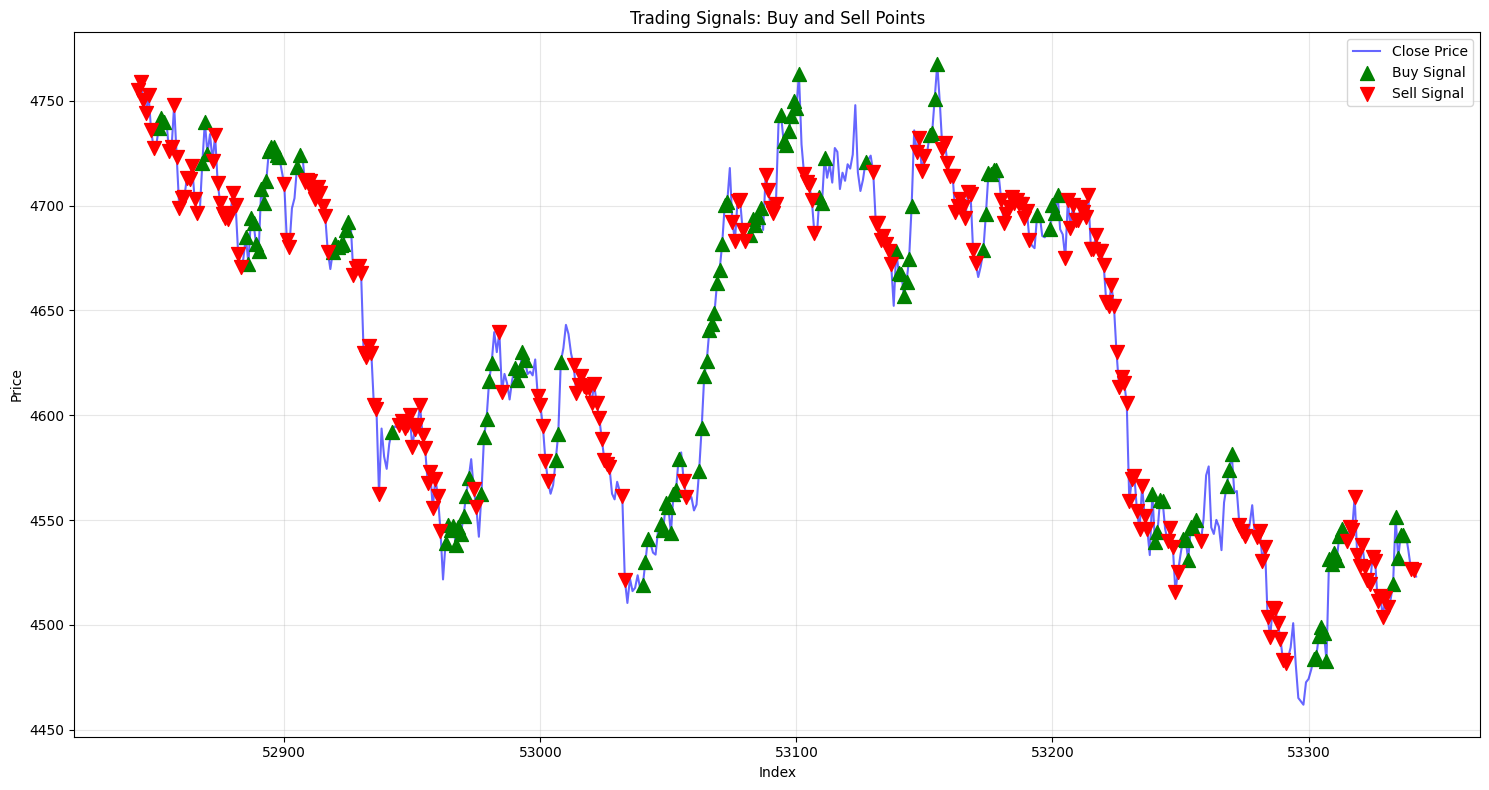


Signal Distribution:
Hold/No Action (0): 127
Buy Signals (1): 146
Sell Signals (2): 227


In [8]:

# Step 5: Visualize signals
print("\nStep 5: Visualizing trading signals...")
plot_signals(df[-500:])



In [9]:
print(f"Data loaded: {len(df)} rows")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data loaded: 53343 rows
Memory usage: 10.61 MB


In [10]:
df

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,...,low_1d,close_1d,volume_1d,month,day,hour,day_of_week,label,label_name,label_conf
0,803.70,807.70,792.00,792.80,11292,803.70,807.70,792.00,792.80,11292,...,792.00,792.80,11292,11,29,0,3,0,hold,0.541
1,793.30,799.20,778.70,782.70,11315,793.30,799.20,778.70,782.70,11315,...,778.70,782.70,11315,11,30,0,4,0,hold,0.464
2,783.80,794.50,776.80,794.30,9936,783.80,794.50,776.80,794.30,9936,...,776.80,794.30,9936,12,3,0,0,0,hold,0.332
3,793.60,805.00,786.20,800.60,9730,793.60,805.00,786.20,800.60,9730,...,786.20,800.60,9730,12,4,0,1,0,hold,0.332
4,801.00,806.50,790.80,794.80,11035,801.00,806.50,790.80,794.80,11035,...,790.80,794.80,11035,12,5,0,2,0,hold,0.494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53338,4541.90,4545.89,4539.57,4543.16,4129,4541.90,4545.89,4525.41,4526.57,21397,...,4490.51,4509.11,281818,5,22,1,4,0,hold,0.141
53339,4543.13,4544.86,4532.42,4535.41,4853,4541.90,4545.89,4525.41,4526.57,21397,...,4490.51,4509.11,281818,5,22,2,4,0,hold,0.356
53340,4535.71,4540.96,4525.41,4526.57,12415,4541.90,4545.89,4525.41,4526.57,21397,...,4490.51,4509.11,281818,5,22,3,4,2,sell,0.450
53341,4526.54,4536.06,4521.01,4526.26,15410,4526.54,4536.06,4518.53,4527.11,41506,...,4490.51,4509.11,281818,5,22,4,4,2,sell,0.315


In [11]:
# Prepare features and labels

feature_cols = ['open', 'high', 'low', 'close', 'volume',"open_4h","high_4h","low_4h","close_4h","volume_4h","open_1d","high_1d","low_1d","close_1d","volume_1d",
                'hour', 'day', 'month','day_of_week']
                
X = df[feature_cols].values
y = df['label'].values
#df = None
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X , y = None, None



In [12]:
print(X_train.shape)

(48008, 19)


In [13]:
print("\n" + "="*70)
print("TRAINING CLASSIFICATION MODELS")
print("="*70)
model = RandomForestClassifier(n_estimators=300, n_jobs=4, random_state=42, verbose=2)
# Train
model.fit(X_train, y_train)
X_train, y_train = None, None
# Predict
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


TRAINING CLASSIFICATION MODELS


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300


[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    6.2s


building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80

[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   28.3s


building tree 159 of 300
building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300


[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:   53.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    0.1s


Accuracy: 0.7738

Confusion Matrix:
[[1059  291  265]
 [ 301 1630   34]
 [ 253   63 1439]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66      1615
           1       0.82      0.83      0.83      1965
           2       0.83      0.82      0.82      1755

    accuracy                           0.77      5335
   macro avg       0.77      0.77      0.77      5335
weighted avg       0.77      0.77      0.77      5335



[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.2s finished


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.0s finished
e:\GitHub\Dbot-Advance\extra_function.py:625: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_label'] = model.predict(X)


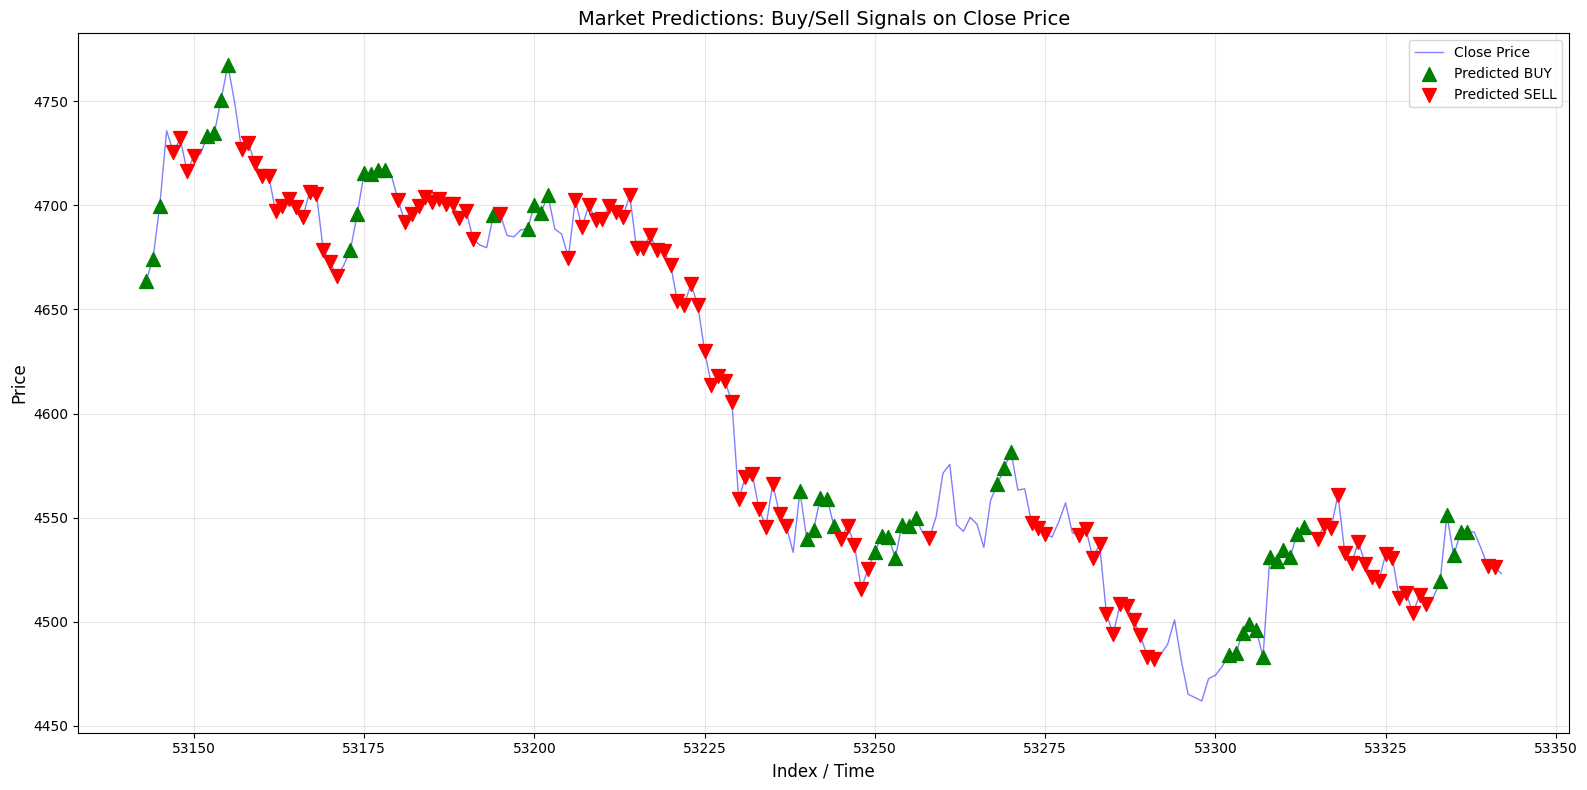


Signal Distribution:
Hold/No Action (0): 44
Buy Signals (1): 51
Sell Signals (2): 105


In [14]:

# --- Example Usage ---
# Ensure your 'df' has gone through engineer_features() first
# features = ['open', 'high', 'low', 'volume', 'month', 'day', 'hour', 'minute', 'day_of_week']
predict_and_plot_signals(model, df[-200:], feature_cols)